# Projet DCGAN — Génération de visages Anime

## Introduction :
notebook entraîne un DCGAN (Deep Convolutional GAN) pour générer des visages de style anime, avec les stabilisations suivantes : label smoothing, bruit d'instance décroissant, learning rates différenciés D/G, et Spectral Normalization sur le discriminateur.
La qualité est évaluée avec le FID (Fréchet Inception Distance) et le suivi de D(x) / D(G(z)) au fil de l'entraînement.

## 1. Installation et importation des dépendances

In [ ]:
!pip install kagglehub
import kagglehub
import os
import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torch
import matplotlib.pyplot as plt
import shutil
import numpy as np



## 2. Téléchargement du dataset (Anime Face Dataset) :
Dataset choisi pour sa taille (~60k images), sa résolution native proche de celle utilisée par le générateur (évite l'upscale artificiel), et sa popularité comme référence pour l'entraînement de DCGAN.

In [ ]:
path = kagglehub.dataset_download("splcher/animefacedataset")
print("Path to dataset files:", path)

In [4]:
directory = os.listdir(path)[0]
train_path = os.path.join(path,directory)

## 3. Dataset PyTorch personnalisé :
Classe `Anime` : charge chaque image du dossier et applique la transformation passée en argument. Le label `1` renvoyé n'est pas utilisé par le GAN (pas de classification), c'est juste un espace réservé attendu par la structure `Dataset`.

In [6]:
class Anime(Dataset) :
    def __init__(self, folder_path, transform=None) :
        self.image_paths= glob.glob(os.path.join(folder_path, '*'))
        self.transform = transform
    def __len__(self) :
        return len(self.image_paths)
    def __getitem__(self,idx) :
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform :
            img = self.transform(img)
        return img, 1

## 4. Prétraitement des images **Point critique** :
 `Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))` ramène les pixels de [0,1] vers [-1,1], pour correspondre exactement à la plage de sortie du `Tanh()` du générateur. Sans cette ligne, le discriminateur peut trivialement distinguer réel/faux sur la seule base de la plage de valeurs, indépendamment du contenu visuel.

In [11]:
IMAGE_SIZE = 128
data_tranforms = transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = Anime(folder_path = train_path, transform = data_tranforms)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

## 5. Architecture du Générateur :
5 couches `ConvTranspose2d` (1×1 → 4×4 → 8×8 → 16×16 → 32×32 → 64×64 → 128×128), `BatchNorm2d` + `ReLU` à chaque étape, `Tanh()` final. Résolution 128×128 choisie pour correspondre à la résolution native des images du dataset (pas d'upscale artificiel inutile).

In [15]:
class MyGenerator(nn.Module):
    def __init__(self, noises_size=100, channels=3, kernel_num=64):
        super(MyGenerator, self).__init__()

        self.main = nn.Sequential(
            # Étape 1 : bruit latent (1x1) -> 4x4
            nn.ConvTranspose2d(noises_size, kernel_num * 16, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(kernel_num * 16),
            nn.ReLU(True),

            # Étape 2 : 4x4 -> 8x8
            nn.ConvTranspose2d(kernel_num * 16, kernel_num * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(kernel_num * 8),
            nn.ReLU(True),

            # Étape 3 : 8x8 -> 16x16
            nn.ConvTranspose2d(kernel_num * 8, kernel_num * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(kernel_num * 4),
            nn.ReLU(True),

            # Étape 4 : 16x16 -> 32x32
            nn.ConvTranspose2d(kernel_num * 4, kernel_num * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(kernel_num * 2),
            nn.ReLU(True),

            # Étape 5 : 32x32 -> 64x64
            nn.ConvTranspose2d(kernel_num * 2, kernel_num, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(kernel_num),
            nn.ReLU(True),

            # Étape 6 (Finale) : 64x64 -> 128x128
            nn.ConvTranspose2d(kernel_num, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

## 6. Architecture du Discriminateur :
5 couches `Conv2d` avec **Spectral Normalization** (`nn.utils.spectral_norm`) au lieu de `BatchNorm2d`. La spectral norm contraint chaque couche à une constante de Lipschitz ≤ 1, ce qui empêche le discriminateur de devenir trop confiant trop vite et stabilise le gradient transmis au générateur — corrige le mode collapse .

In [16]:
class MyDiscriminator(nn.Module):
    def __init__(self, channels=3, kernel_num=64):
        super(MyDiscriminator, self).__init__()

        self.main = nn.Sequential(
            # Étape 1 : Entrée 128x128 -> 64x64
            nn.utils.spectral_norm(nn.Conv2d(channels, kernel_num, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Étape 2 : 64x64 -> 32x32
            nn.utils.spectral_norm(nn.Conv2d(kernel_num, kernel_num * 2, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Étape 3 : 32x32 -> 16x16
            nn.utils.spectral_norm(nn.Conv2d(kernel_num * 2, kernel_num * 4, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Étape 4 : 16x16 -> 8x8
            nn.utils.spectral_norm(nn.Conv2d(kernel_num * 4, kernel_num * 8, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Étape 5 : 8x8 -> 4x4
            nn.utils.spectral_norm(nn.Conv2d(kernel_num * 8, kernel_num * 16, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Étape 6 (Finale) : 4x4 -> 1x1
            nn.utils.spectral_norm(nn.Conv2d(kernel_num * 16, 1, kernel_size=4, stride=1, padding=0, bias=False)),
            nn.Sigmoid()
        )

    def forward(self, input):
        output = self.main(input)
        return output.view(-1)

## 7. Connexion à Google Drive (sauvegarde persistante)

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    chemin_dossier = '/content/drive/MyDrive/Projet_GAN_AnimeFaces'
except ImportError:
    chemin_dossier = './outputs'  # exécution locale

os.makedirs(chemin_dossier, exist_ok=True)
print(f"Les images seront sauvegardées ici : {chemin_dossier}")

## 8. Boucle d'entraînement :
Stabilisations appliquées :
- **Label smoothing** (`real_labels = 0.9`) : évite un discriminateur trop confiant
- **Bruit d'instance décroissant** (`noise_std`) : empêche D d'apprendre un raccourci trivial en début d'entraînement
- **Learning rates différenciés** (`lrD=0.0001 < lrG=0.0002`) : ralentit D par rapport à G
- **Logging D(x) / D(G(z))** : suivi de la convergence vers l'équilibre théorique (~0.5)
- **Checkpointing tous les 10 epochs** : robustesse face aux déconnexions Colab> ⚠️

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entraînement sur : {device}")
noises_size = 100

fixed_noise = torch.randn(3, noises_size, 1, 1, device=device)
generator = MyGenerator(noises_size=noises_size, channels=3, kernel_num=64).to(device)
discriminator = MyDiscriminator(channels=3, kernel_num=64).to(device)

criterion = nn.BCELoss()
lrD = 0.0001
lrG = 0.0002
optimizerD = optim.Adam(discriminator.parameters(), lr=lrD, betas=(0.5, 0.999))
optimizerG = optim.Adam(generator.parameters(), lr=lrG, betas=(0.5, 0.999))
num_epochs = 150

# Listes pour stocker l'historique (pour les courbes après entraînement)
losses_D, losses_G = [], []
D_x_list, D_Gz_list = [], []

for epoch in range(num_epochs):
    # Accumulateurs pour la moyenne par epoch
    epoch_lossD, epoch_lossG = 0.0, 0.0
    epoch_Dx, epoch_DGz = 0.0, 0.0
    nb_batches = 0

    for i, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)
        bruit = torch.randn(batch_size, noises_size, 1, 1, device=device)
        out_generator = generator(bruit)

        noise_std = max(0.05 * (1 - epoch / num_epochs), 0)
        outD_r = discriminator(real_images + torch.randn_like(real_images) * noise_std)
        outD_f = discriminator(out_generator.detach())
        real_labels = torch.ones(batch_size, device=device) * 0.9
        fake_labels = torch.zeros(batch_size, device=device)
        LossD_r = criterion(outD_r, real_labels)
        LossD_f = criterion(outD_f, fake_labels)
        LossD = LossD_r + LossD_f

        optimizerD.zero_grad()
        LossD.backward()
        optimizerD.step()

        outD_f = discriminator(out_generator)
        LossG = criterion(outD_f, real_labels)
        optimizerG.zero_grad()
        LossG.backward()
        optimizerG.step()

        # --- Logging D(x) et D(G(z)) ---
        epoch_lossD += LossD.item()
        epoch_lossG += LossG.item()
        epoch_Dx += outD_r.mean().item()
        epoch_DGz += outD_f.mean().item()
        nb_batches += 1

        if i % 50 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] | Loss D: {LossD.item():.4f} | Loss G: {LossG.item():.4f} | D(x): {outD_r.mean().item():.4f} | D(G(z)): {outD_f.mean().item():.4f}")

    # Moyenne sur toute l'epoch, stockée pour les courbes
    losses_D.append(epoch_lossD / nb_batches)
    losses_G.append(epoch_lossG / nb_batches)
    D_x_list.append(epoch_Dx / nb_batches)
    D_Gz_list.append(epoch_DGz / nb_batches)

    # Optionnel : générer des images pour suivre l’avancement à chaque epoch
    generator.eval()
    with torch.no_grad():
        image_brute = generator(fixed_noise).detach().cpu()
        tenseur = (image_brute + 1) / 2.0
        for j in range(tenseur.size(0)):
            convertisseur = T.ToPILImage()
            vraie_image = convertisseur(tenseur[j])
            chemin_complet = f"{chemin_dossier}/anime_epoque_{epoch}_{j}.jpg"
            vraie_image.save(chemin_complet)
    generator.train()

    # Checkpoint de sécurité tous les 10 epochs
    if epoch % 10 == 0:
        torch.save(generator.state_dict(), f"{chemin_dossier}/generator_epoch{epoch}.pth")
        torch.save(discriminator.state_dict(), f"{chemin_dossier}/discriminator_epoch{epoch}.pth")

torch.save(generator.state_dict(), f"{chemin_dossier}/generator.pth")
torch.save(discriminator.state_dict(), f"{chemin_dossier}/discriminator.pth")
print("Modèles sauvegardés avec succès !")

## Suppression des checkpoints temporaires :

In [ ]:
checkpoints_gen = glob.glob(f"{chemin_dossier}/generator_epoch*.pth")
checkpoints_disc = glob.glob(f"{chemin_dossier}/discriminator_epoch*.pth")

for f in checkpoints_gen + checkpoints_disc:
    os.remove(f)
    print(f"Supprimé : {f}")

print(f"Fichiers restants : {os.listdir(chemin_dossier)}")

## 9. Préparation du dossier d'images réelles (pour le FID) :
Copie d'un échantillon (500 images) du dataset réel dans un dossier séparé, utilisé comme référence de comparaison pour le calcul du FID.

In [ ]:

dossier_reel = f"{chemin_dossier}/fid_real"
dossier_genere = f"{chemin_dossier}/fid_fake"

os.makedirs(dossier_reel, exist_ok=True)
os.makedirs(dossier_genere, exist_ok=True)

tous_fichiers = os.listdir(train_path)
for f in tous_fichiers[:500]:
    shutil.copy(os.path.join(train_path, f), dossier_reel)

print(f"{len(os.listdir(dossier_reel))} images réelles copiées.")

## 10. Génération d'images (pour le FID) :
Génération de 500 images avec des bruits **différents** à chaque fois.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = MyGenerator(noises_size=noises_size, channels=3, kernel_num=64).to(device)
generator.load_state_dict(torch.load(f"{chemin_dossier}/generator.pth", map_location=device))
generator.eval()
with torch.no_grad():
    for i in range(500):
        bruit = torch.randn(1, noises_size, 1, 1, device=device)
        fake = generator(bruit).detach().cpu()
        fake = (fake + 1) / 2.0
        img = transforms.ToPILImage()(fake.squeeze(0))
        img.save(f"{dossier_genere}/fake_{i}.jpg")
print(f"{len(os.listdir(dossier_reel))} images générées.")

## 11. Installation de `pytorch-fid`

In [ ]:
!pip install pytorch-fid --break-system-packages

## 12. Uniformisation des tailles d'image**Correctif nécessaire** :
`pytorch-fid` empile les images par batch avant de les redimensionner à 299×299 pour Inception v3. Si les images sources ont des tailles natives différentes (ex: 73×73 vs 67×67), `torch.stack` échoue. Cette étape uniformise toutes les images à une taille commune (128×128) avant le calcul du FID.

In [ ]:
def uniformiser_dossier(dossier, taille=128):
    for fichier in os.listdir(dossier):
        chemin = os.path.join(dossier, fichier)
        try:
            img = Image.open(chemin).convert("RGB")
            img = img.resize((taille, taille), Image.BICUBIC)
            img.save(chemin)
        except Exception as e:
            print(f"Erreur sur {fichier}: {e}")

uniformiser_dossier(dossier_reel, taille=128)
uniformiser_dossier(dossier_genere, taille=128)

print("Images uniformisées.")

## 13. Calcul du FID :


In [ ]:
from pytorch_fid import fid_score

fid_value = fid_score.calculate_fid_given_paths(
    [dossier_reel, dossier_genere],
    batch_size=32,
    device=device,
    dims=2048
)
print(f"FID: {fid_value:.2f}")

## 14. Visualisation des courbes d'entraînement :
Loss D/G et convergence de D(x)/D(G(z)) vers l'équilibre théorique (0.5).

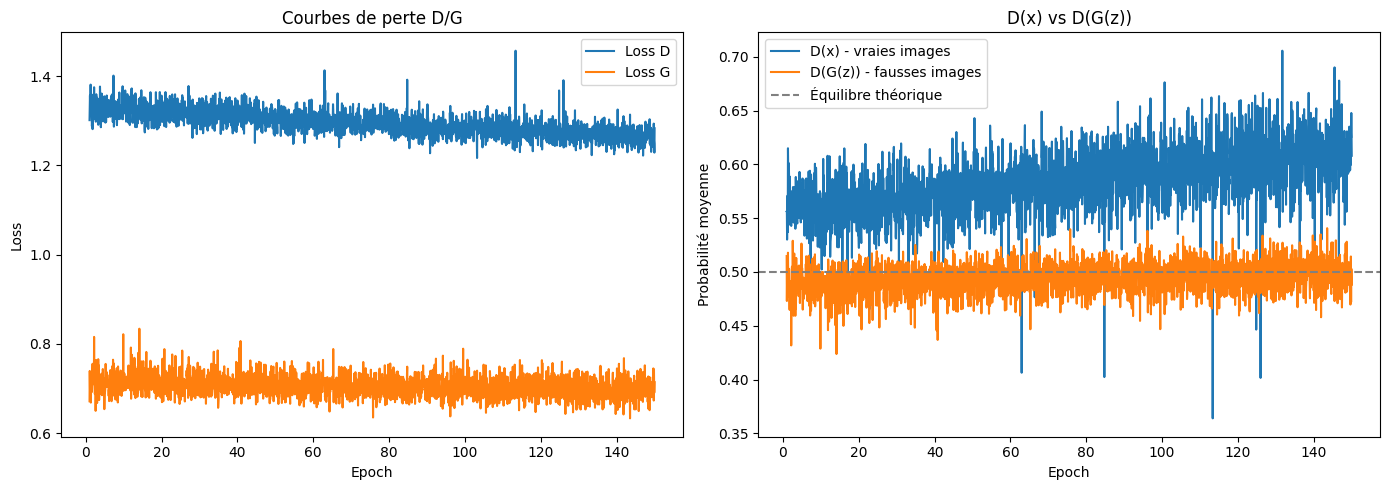

In [25]:


x_epochs = np.linspace(1, num_epochs, len(losses_D))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_epochs, losses_D, label="Loss D")
axes[0].plot(x_epochs, losses_G, label="Loss G")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Courbes de perte D/G")
axes[0].legend()

axes[1].plot(x_epochs, D_x_list, label="D(x) - vraies images")
axes[1].plot(x_epochs, D_Gz_list, label="D(G(z)) - fausses images")
axes[1].axhline(0.5, color='gray', linestyle='--', label="Équilibre théorique")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Probabilité moyenne")
axes[1].set_title("D(x) vs D(G(z))")
axes[1].legend()

plt.tight_layout()

plt.savefig(f"{chemin_dossier}/courbes_entrainement.png")
plt.show()